# Whakaari data construction

This notebook builds the hourly Whakaari dataset used by the Cause–Trigger analysis. It retains six variables: three waveform-derived observables, rainfall, pressure drop, and the lagged GNSS deformation-rate proxy.

In [8]:
import sys
from pathlib import Path
import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    TILDE_DATA_URL,
    WHAKAARI_ANALYSIS_COLUMNS,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_START,
    WHAKAARI_WAVEFORM_CONFIG,
    whakaari_observable_metadata,
)
from whakaari_dataset import (
    build_main_dataframe,
    prepare_analysis_dataframe,
    preprocessing_report,
    save_whakaari_analysis_dataset,
)
from whakaari_geonet import (
    load_gnss_deformation,
    load_weather_vars,
)
from whakaari_plotting_utils import (
    dataset_health_report,
    distribution_summary,
    plot_whakaari_all_variables_map,
    plot_whakaari_loglog_distributions,
    plot_whakaari_thesis_figures,
)
from whakaari_waveform import build_waveform_dataset

BUFFER_START = (
    pd.Timestamp(WHAKAARI_START, tz="UTC") - pd.Timedelta(days=2)
).strftime("%Y-%m-%d")

## External variables

GNSS displacement is downloaded for RGWC and RGWI and converted to their vertical-displacement difference. The past-only daily change is constructed later. Weather data are cached and include hourly precipitation and pressure drop.

In [9]:
gnss = load_gnss_deformation(
    tilde_data_base_url=TILDE_DATA_URL,
    start=BUFFER_START,
    end=WHAKAARI_END,
    cache_path="../data/whakaari/whakaari_gnss_deformation.csv",
    redownload=False, # True to redownload, False to load cache
)

weather_vars = load_weather_vars(
    lat=WHAKAARI_LAT,
    lon=WHAKAARI_LON,
    start=BUFFER_START,
    end=WHAKAARI_END,
    cache_path="../data/whakaari/whakaari_openmeteo.csv",
    redownload=False, # True to redownload, False to load cache
)

gnss_days_all = pd.DatetimeIndex(
    pd.to_datetime(gnss.index, utc=True)
).normalize()
gnss_days = gnss_days_all.unique()

expected_gnss_days = pd.date_range(
    gnss_days.min(),
    gnss_days.max(),
    freq="1D",
)

gnss_audit = pd.DataFrame([{
    "dataset": "GNSS deformation level",
    "rows": len(gnss),
    "start_day": gnss_days.min(),
    "end_day": gnss_days.max(),
    "duplicate_days": int(gnss_days_all.duplicated().sum()),
    "missing_daily_dates": len(
        expected_gnss_days.difference(gnss_days)
    ),
    "missing_values": int(gnss.isna().sum().sum()),
}])

display(gnss_audit)
display(dataset_health_report(weather_vars, "Open-Meteo variables"))

,dataset,rows,start_day,end_day,duplicate_days,missing_daily_dates,missing_values
0,GNSS deformation level,79,2019-09-29 00:00:00+00:00,2019-12-16 00:00:00+00:00,0,0,0


,name,rows,variables,start,end,duplicate_timestamps,time_sorted,missing_hourly_timestamps,missing_values
0,Open-Meteo variables,1895,2,2019-09-29 01:00:00+00:00,2019-12-16 23:00:00+00:00,0,True,0,0


## Waveform features

WSRZ HHZ data are processed into hydrothermal RMS, a past-smoothed spectral contrast, and the 5–15 Hz tremor-response anomaly. The cache also preserves any day-level extraction failures.

In [10]:
waveform_df, waveform_failures = build_waveform_dataset(
    client=Client("GEONET"),
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path="../data/whakaari/whakaari_waveform.pkl",
    overwrite=False, # True to redownload, False to load cache
)

print(f"Waveform rows: {len(waveform_df)}")
print(f"Failed daily chunks: {len(waveform_failures)}")

if waveform_failures:
    display(pd.DataFrame(
        waveform_failures,
        columns=["date", "error"],
    ))

Waveform rows: 1848
Failed daily chunks: 0


## Save hourly dataset

All sources are aligned to the same hourly grid. The GNSS value used during day \(D\) is the deformation change from \(D-2\) to \(D-1\), so it is past-only. Rows unresolved in any retained variable are removed without interpolating long waveform gaps.

In [11]:
whakaari_main = build_main_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    gnss=gnss,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
)

whakaari_dataset = prepare_analysis_dataframe(
    whakaari_main,
    required_columns=WHAKAARI_ANALYSIS_COLUMNS,
)

construction = preprocessing_report(
    rawest_df=whakaari_main,
    prepared_df=whakaari_dataset,
)

dataset_path = save_whakaari_analysis_dataset(
    whakaari_dataset,
    output_dir="../data/whakaari",
)

display(construction["summary"])
display(construction["missing_by_variable"])
display(construction["dropped_ranges"])
display(dataset_health_report(whakaari_dataset, "Whakaari dataset"))
display(distribution_summary(whakaari_dataset))

print(f"Saved: {dataset_path}")

,main_rows,analysis_rows,rows_removed,analysis_start,analysis_end,duplicate_timestamps,remaining_missing_values
0,1848,1826,22,2019-10-01 12:00:00+00:00,2019-12-16 23:00:00+00:00,0,0


,variable,missing_in_main,missing_in_analysis
0,hydro_2_5,7,0
1,spectral_log_ratio_4p5_8_over_8_16,8,0
2,effect_tremor_5_15,19,0
3,rainfall_mm,0,0
4,pressure_drop,0,0
5,GNSS_deformation_rate,0,0


,start,end,hours
0,2019-10-01 00:00:00+00:00,2019-10-01 11:00:00+00:00,12
1,2019-11-04 00:00:00+00:00,2019-11-04 00:00:00+00:00,1
2,2019-11-18 22:00:00+00:00,2019-11-19 06:00:00+00:00,9


,name,rows,variables,start,end,duplicate_timestamps,time_sorted,missing_hourly_timestamps,missing_values
0,Whakaari dataset,1826,6,2019-10-01 12:00:00+00:00,2019-12-16 23:00:00+00:00,0,True,10,0


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
GNSS_deformation_rate,1826.0,0.000013,0.003497,-8.880000e-03,0.000110,0.008900,-0.240029,77,0.0
effect_tremor_5_15,1826.0,0.098195,0.212870,0.000000e+00,0.008906,2.163173,4.360358,1005,0.0
hydro_2_5,1826.0,0.000002,0.000002,3.226971e-07,0.000002,0.000019,4.821315,1826,0.0
pressure_drop,1826.0,-0.001643,0.448813,-1.800000e+00,0.000000,1.800000,0.072629,57,0.0
rainfall_mm,1826.0,0.100274,0.417291,0.000000e+00,0.000000,6.900000,7.067049,36,0.0
spectral_log_ratio_4p5_8_over_8_16,1826.0,0.414317,0.342278,-6.421713e-01,0.533904,0.969692,-1.071101,1396,0.0


Saved: ..\data\whakaari\whakaari_dataset.csv


The removed rows comprise the initial 12-hour proxy warm-up, one isolated waveform-affected hour at 2019-11-04 00:00 UTC, and nine waveform-affected hours from 2019-11-18 22:00 to 2019-11-19 06:00 UTC. These rows are omitted rather than imputed.

### Log-log distribution diagnostics

These diagnostics use all six unscaled variables, including GNSS. True logarithmic axes require positive values, so zeros and negative observations are excluded variable by variable and reported explicitly.

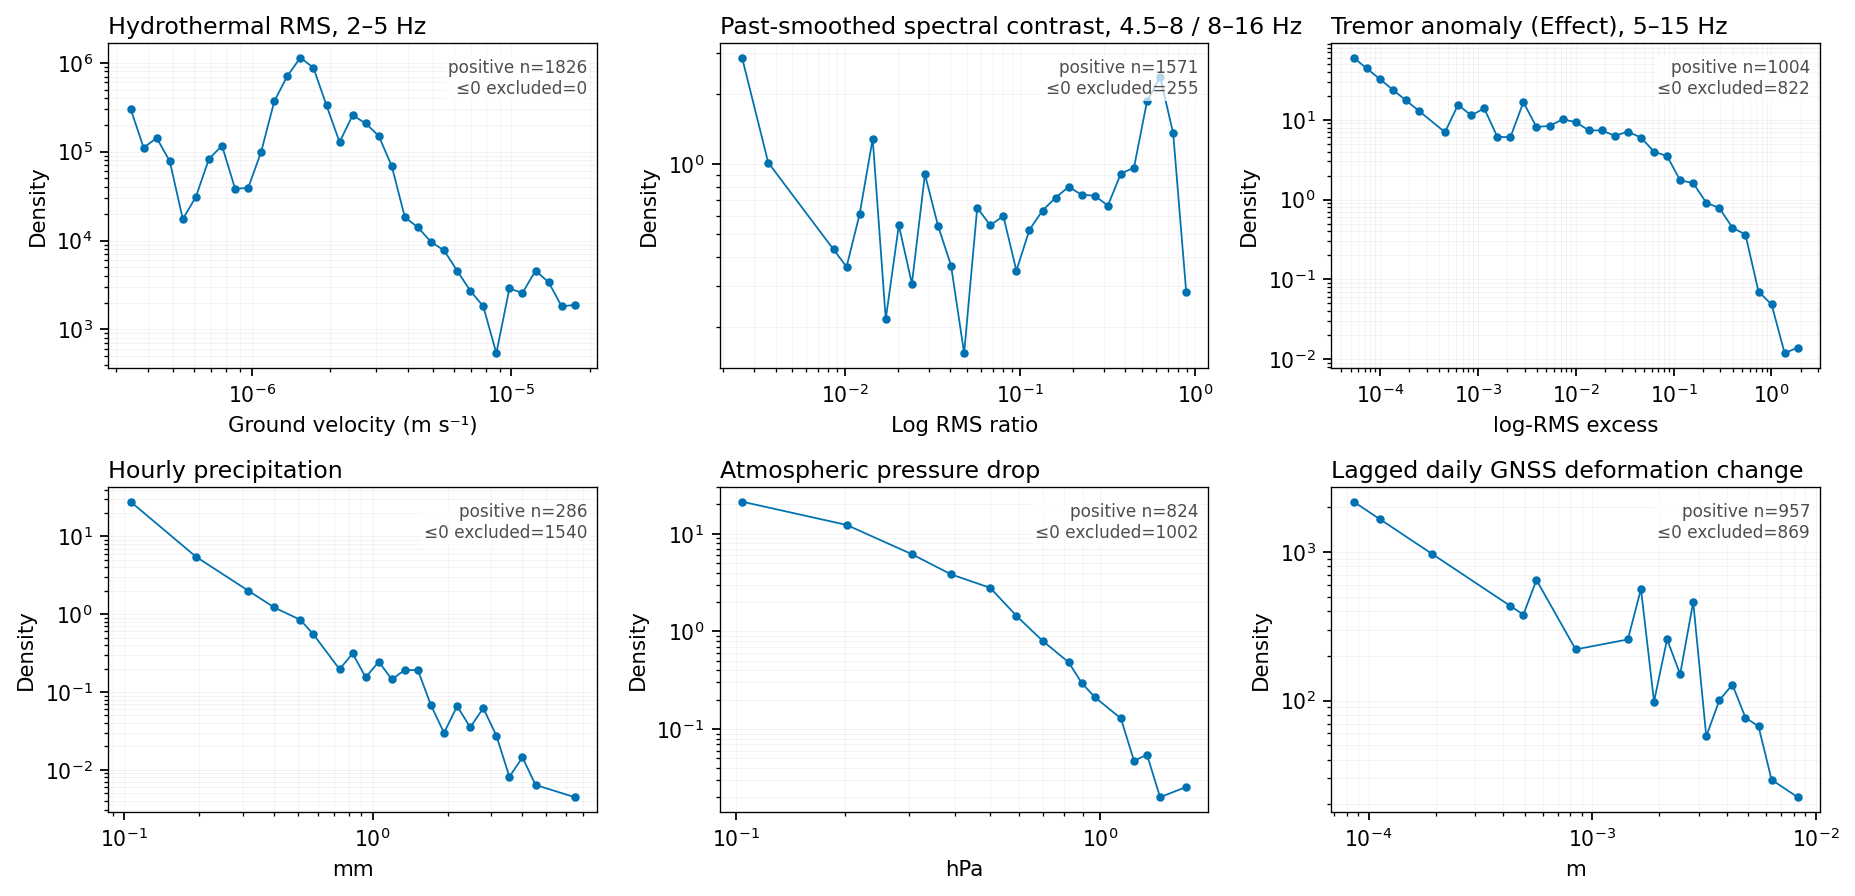

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_excluded,positive_fraction,min_positive,max_positive,n_unique_positive
0,hydro_2_5,1826,1826,0,1.000000,3.226971e-07,0.000019,1826
1,spectral_log_ratio_4p5_8_over_8_16,1826,1571,255,0.860350,2.363047e-03,0.969692,1207
2,effect_tremor_5_15,1826,1004,822,0.549836,4.605966e-05,2.163173,1004
3,rainfall_mm,1826,286,1540,0.156627,1.000000e-01,6.900000,35
4,pressure_drop,1826,824,1002,0.451260,1.000000e-01,1.800000,29
5,GNSS_deformation_rate,1826,957,869,0.524096,8.000000e-05,0.008900,40


In [12]:
_, _, whakaari_loglog_report = plot_whakaari_loglog_distributions(
    dataframe=whakaari_dataset,
    save_dir="../figures",
)

display(whakaari_loglog_report)

### Final overview figures

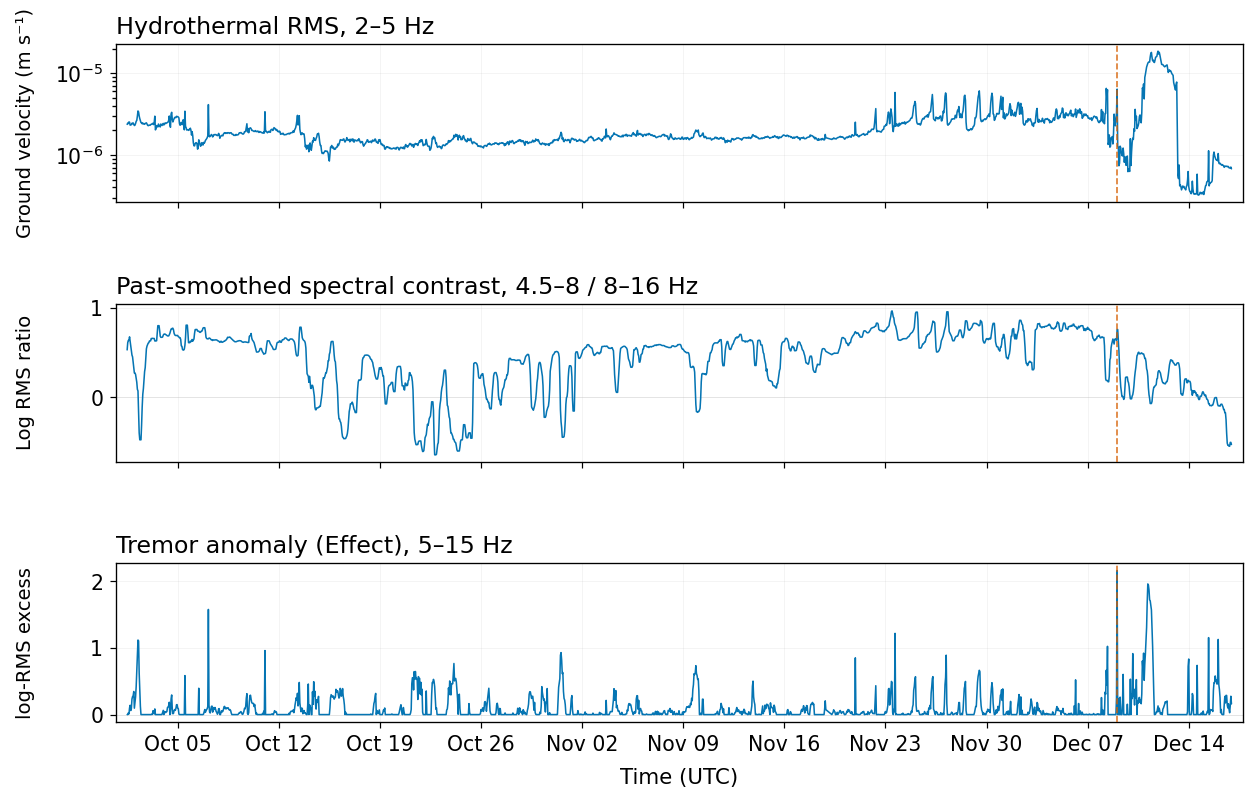

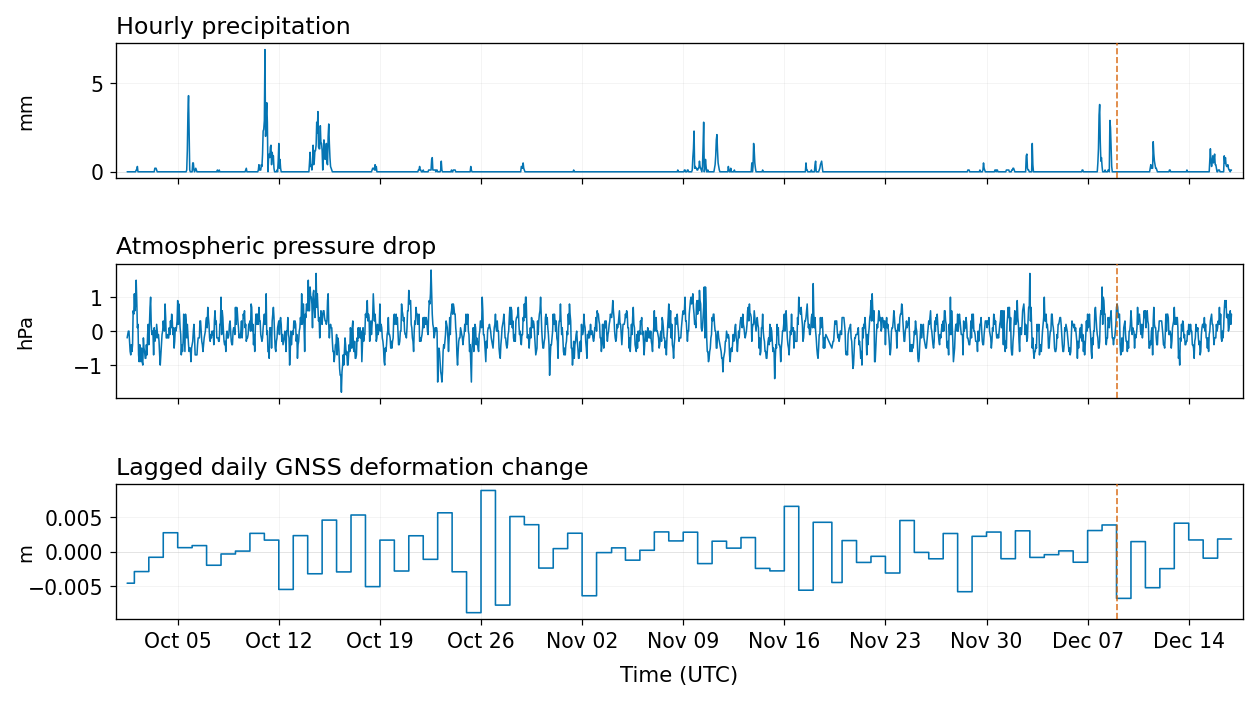

((<Figure size 1280x761.6 with 3 Axes>,
  array([<Axes: title={'left': 'Hydrothermal RMS, 2–5 Hz'}, ylabel='Ground velocity (m s⁻¹)'>,
         <Axes: title={'left': 'Past-smoothed spectral contrast, 4.5–8 / 8–16 Hz'}, ylabel='Log RMS ratio'>,
         <Axes: title={'left': 'Tremor anomaly (Effect), 5–15 Hz'}, xlabel='Time (UTC)', ylabel='log-RMS excess'>],
        dtype=object)),
 (<Figure size 1280x646.4 with 3 Axes>,
  array([<Axes: title={'left': 'Hourly precipitation'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'Lagged daily GNSS deformation change'}, xlabel='Time (UTC)', ylabel='m'>],
        dtype=object)))

In [13]:
plot_whakaari_thesis_figures(
    csv_path=dataset_path,
    eruption_time=WHAKAARI_ERUPTION_TIME,
    save_dir="../figures",
    include_titles=False,
)

### Geographic Visualization

,Source,Source ID,Variables,Internal names
0,Open-Meteo,WHAKAARI_OPENMETEO_PROXY,Hourly precipitation; Atmospheric pressure drop,"rainfall_mm, pressure_drop"
1,RGWC–RGWI midpoint,RGWC_RGWI,Lagged daily GNSS deformation change,GNSS_deformation_rate
2,WSRZ,WSRZ,"Hydrothermal tremor RMS, 2–5 Hz; Past-smoothed...","hydro_2_5, spectral_log_ratio_4p5_8_over_8_16,..."


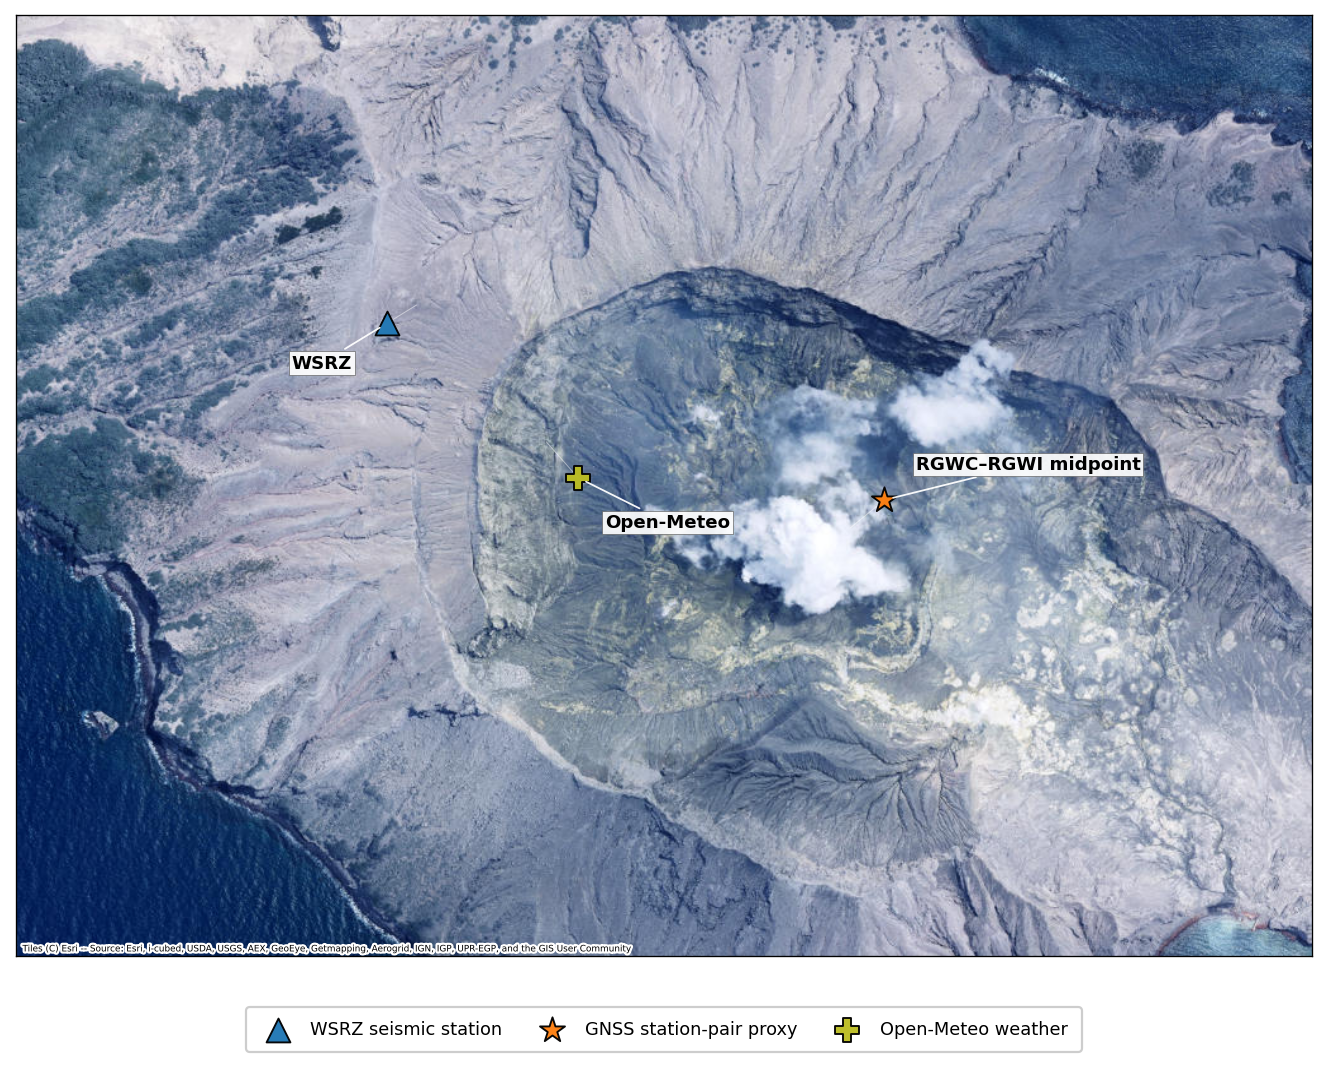

In [14]:
metadata = whakaari_observable_metadata()

fig, ax, variable_table = plot_whakaari_all_variables_map(
    metadata=metadata,
    satellite=True,
    save_dir="../figures",
    filename="whakaari_map",
)

display(variable_table)